In [1]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

# Add XAIensembler to python path
sys.path.append(os.path.join(os.getcwd(), 'XAIensembler'))

import XAIensembler.params as params
import XAIensembler.modelarch as modelarch
import XAIensembler.thesisArchitecture_LateFusion as thesisArchitecture_LateFusion
from XAIensembler.segmentXAIensembler import ISIC_Dataset
import XAIensembler.metrics as metrics

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# --- Configuration ---
# 1. Update Params Logic
# The issue is that `segmentXAIensembler.py` directly imports `params` (the module).
# When we `import XAIensembler.params as params`, we get a reference to that module.
# BUT `ISIC_Dataset` inside `segmentXAIensembler.py` likely uses `params` from *its* global scope, 
# which it imported via `import params`.
# So updating `params` here updates the module, but we must ensure `segmentXAIensembler` sees it.
# Usually modules are singletons, so modifying attributes on `params` module works globally.

# HOWEVER: The error shows `/content/images/train/melanoma`.
# This comes from the *original values* in `XAIensembler/params.py`.
# It means my updates didn't stick or `ISIC_Dataset` is using deep copies or old values.
# Wait! In ISIC_Dataset.__init__(self, params, ...), it takes `params` as an argument!
# Let's check `read_dataset` call: `self.read_dataset(self.root, self.phase)`.
# Inside `read_dataset`:
# 541: tmp_list_of_images = os.listdir(image_root)
# But `image_root` calculation depends on `params`. 
# THE ISSUE: `read_dataset` implementation in `segmentXAIensembler.py`:
# It likely uses GLOBAL `params` from imports, NOT `self.params`.
# Let's check the code of `read_dataset` again.
# "image_root = os.path.join(params.image_train_path, image_class)"
# If it says just `params.`, it refers to the `import params` at the top of that file.

# FIX: We need to monkey-patch `XAIensembler.segmentXAIensembler.params` to be OUR params module.
import XAIensembler.segmentXAIensembler as seg

root = os.getcwd()
data_root = os.path.join(root, "data")

# Construct paths
my_image_train = os.path.join(data_root, "images/train")
my_mask_train = os.path.join(data_root, "masks/train")
my_image_val = os.path.join(data_root, "images/validation")
my_mask_val = os.path.join(data_root, "masks/validation")
my_image_test = os.path.join(data_root, "images/test")
my_mask_test = os.path.join(data_root, "masks/test")

# Update BOTH references
params.image_train_path = my_image_train
params.mask_train_path = my_mask_train
params.image_validation_path = my_image_val
params.mask_validation_path = my_mask_val
params.image_test_path = my_image_test
params.mask_test_path = my_mask_test
params.root_path = root

# Monkey Patch
seg.params = params

# Also ensure output directory exists for default params usage
# although we override paths, some might be hardcoded as fallback? No.

# 2. XAI Methods Configuration
params.XAI_methods = ["IntegratedGradients", "DeepLift"]

# 3. Load SqueezeNet
num_classes = 3
squeezenet = models.squeezenet1_1(weights=None)
squeezenet.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1, 1), stride=(1, 1))
squeezenet.num_classes = num_classes

weights_path = "squeezenet_skin.pth"
if os.path.exists(weights_path):
    print(f"Loading SqueezeNet weights from {weights_path}")
    state_dict = torch.load(weights_path, map_location=device)
    squeezenet.load_state_dict(state_dict)
else:
    raise FileNotFoundError(f"Missing {weights_path}")

squeezenet.to(device)
squeezenet.eval()

params.explained_model = squeezenet
params.device = device
params.input_size = (224, 224)
params.batch_size = 4
params.image_class = "melanoma" # Default class if needed

print("Configuration patched.")
print(f"Train Path in seg.params: {seg.params.image_train_path}")

Loading SqueezeNet weights from squeezenet_skin.pth
Configuration patched.
Train Path in seg.params: /Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/data/images/train


In [6]:
# --- Dataset Initialization ---

# ISIC_Dataset behaves slightly differently than standard torch datasets
# It computes XAI on __getitem__.
# For training Late Fusion, we need:
# Input: Stacked Explanations (from SqueezeNet)
# Target: Ground Truth Mask

print("Initializing Training Dataset...")
train_dataset = ISIC_Dataset(params, params.root_path, phase="train")
print(f"Train samples: {len(train_dataset)}")

print("Initializing Validation Dataset...")
# Use 'test' phase logic for validation to avoid augmentations if desired
# But ISIC_Dataset uses 'phase' argument for folder selection too.
# Let's verify params paths.
val_dataset = ISIC_Dataset(params, params.root_path, phase="validation")
print(f"Val samples: {len(val_dataset)}")

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=params.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

Initializing Training Dataset...
Train samples: 56
Initializing Validation Dataset...
Val samples: 12


In [7]:
# --- Model Initialization ---

# params.XAI_methods determines the architecture size
model = thesisArchitecture_LateFusion.EnsembleExplanationNetwork(params).to(device)

# Loss and Optimizer
criterion = metrics.dice_bce_loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Late Fusion Model Initialized.")

Late Fusion Model Initialized.


Starting training... (This might be slow due to on-the-fly XAI generation)


/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


Epoch 1, Batch 0, Loss: 0.6879
Epoch 1, Batch 5, Loss: 0.6826
Epoch 1, Batch 10, Loss: 0.6590
Epoch 1/10 - Train Loss: 0.6762 - Val Loss: 0.6903
Epoch 2, Batch 0, Loss: 0.6516
Epoch 2, Batch 5, Loss: 0.6309
Epoch 2, Batch 10, Loss: 0.6043
Epoch 2/10 - Train Loss: 0.6323 - Val Loss: 0.6877
Epoch 3, Batch 0, Loss: 0.5847
Epoch 3, Batch 5, Loss: 0.6153
Epoch 3, Batch 10, Loss: 0.5499
Epoch 3/10 - Train Loss: 0.5685 - Val Loss: 0.6998
Epoch 4, Batch 0, Loss: 0.5515
Epoch 4, Batch 5, Loss: 0.5026
Epoch 4, Batch 10, Loss: 0.4884
Epoch 4/10 - Train Loss: 0.5177 - Val Loss: 0.6402
Epoch 5, Batch 0, Loss: 0.5079
Epoch 5, Batch 5, Loss: 0.4552
Epoch 5, Batch 10, Loss: 0.4524
Epoch 5/10 - Train Loss: 0.4842 - Val Loss: 0.6385
Epoch 6, Batch 0, Loss: 0.5014
Epoch 6, Batch 5, Loss: 0.4522
Epoch 6, Batch 10, Loss: 0.4950
Epoch 6/10 - Train Loss: 0.4741 - Val Loss: 0.6223
Epoch 7, Batch 0, Loss: 0.4586
Epoch 7, Batch 5, Loss: 0.4953
Epoch 7, Batch 10, Loss: 0.4430
Epoch 7/10 - Train Loss: 0.4583 - Va

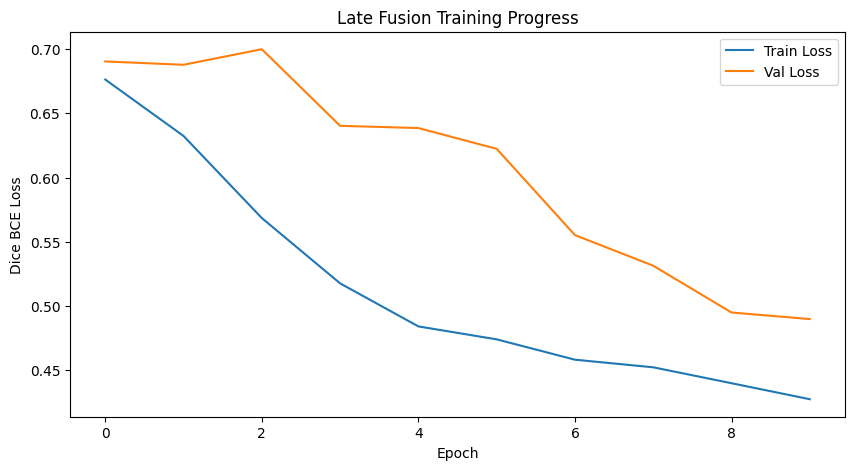

In [8]:
# --- Training Loop ---

num_epochs = 10
train_losses = []
val_losses = []

print("Starting training... (This might be slow due to on-the-fly XAI generation)")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    # Training
    for i, data in enumerate(train_loader):
        # Unpack data
        # Dataset returns: expl, mask, preds, img
        # expl shape: (B, C*Methods, H, W)
        # mask shape: (B, 1, H, W)
        
        explanations = data[0].to(device)
        masks = data[1].to(device)
        
        optimizer.zero_grad()
        
        # Forward
        # Model returns: pred_mask, ensemble_expl
        pred_mask, _ = model.forward(params, explanations)
        
        # Loss
        loss = criterion(masks, pred_mask)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if i % 5 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")
            
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            explanations = data[0].to(device)
            masks = data[1].to(device)
            
            pred_mask, _ = model.forward(params, explanations)
            loss = criterion(masks, pred_mask)
            val_running_loss += loss.item()
            
    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # Save checkpoint
    torch.save(model.state_dict(), f"late_fusion_epoch_{epoch+1}.pth")

print("Training Complete.")

# Plot Losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Late Fusion Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Dice BCE Loss")
plt.legend()
plt.show()


--- Testing on Test Set ---


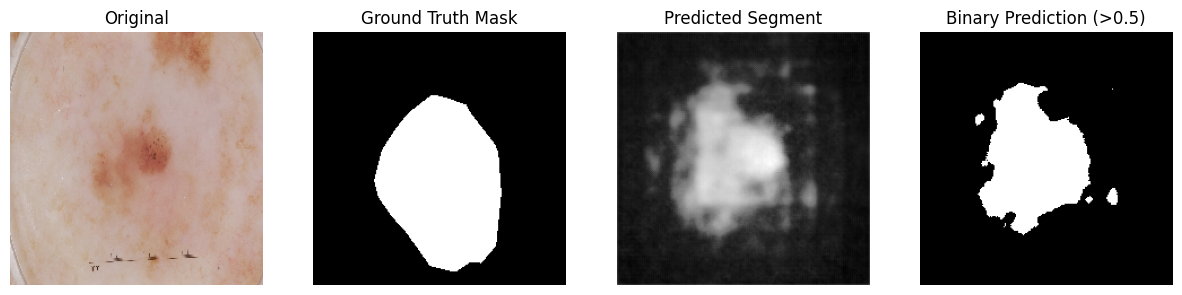

In [9]:
# --- Test & Visualize ---

print("\n--- Testing on Test Set ---")
test_dataset = ISIC_Dataset(params, params.root_path, phase="test")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

sample = next(iter(test_loader))
expl = sample[0].to(device)
mask = sample[1].to(device)
img_raw = sample[3].numpy()[0] # (H, W, 3) BGR

model.eval()
with torch.no_grad():
    pred, ens_expl = model.forward(params, expl)
    
pred_np = pred.squeeze().cpu().numpy()
mask_np = mask.squeeze().cpu().numpy()

# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_raw[..., ::-1]) # RGB
plt.title("Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask_np, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(pred_np, cmap='gray')
plt.title("Predicted Segment")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(pred_np > 0.5, cmap='gray')
plt.title("Binary Prediction (>0.5)")
plt.axis('off')

plt.show()